# Лабораторна робота №1
## Формування нечітких множин та операції над ними

Notebook охоплює всі пункти завдання. Усі графіки автоматично зберігаються у каталозі `figures/`..

In [1]:
from pathlib import Path
import platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import skfuzzy as fuzz

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (10, 5.5), 'figure.dpi': 110, 'savefig.dpi': 200})

print(f'Python: {platform.python_version()}')
print(f'NumPy: {np.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print(f'scikit-fuzzy: {fuzz.__version__}')

Python: 3.14.7
NumPy: 2.5.3
Matplotlib: 3.11.2
scikit-fuzzy: 0.5.0


## ПАРАМЕТРИ

Обмеження: `trimf: a ≤ b ≤ c`; `trapmf: a ≤ b ≤ c ≤ d`; `gaussmf: sigma > 0`; `gauss2mf: mean1 ≤ mean2, sigma1,sigma2 > 0`; `gbellmf: a,b > 0`; `zmf/smf: a ≤ b`; `pimf: a ≤ b ≤ c ≤ d`. Для `sigmf` знак коефіцієнта `c` задає напрям; для віконної `psigmf` зручно брати `c1 > 0`, `c2 < 0`.

In [2]:
# Універсальна множина
X_MIN, X_MAX, STEP = -10, 10.0, 0.01

# Трикутна і трапецієподібна функції
TRI = [-8, -3, 2]                 # [a, b, c]
TRAP = [-1, 2, 5, 8]             # [a, b, c, d]

# Гаусові функції
GAUSS = {'mean': 0, 'sigma': 2}
GAUSS2 = [
    {'mean1': -6, 'sigma1': 1.0, 'mean2': -2, 'sigma2': 1.0},
    {'mean1': -5, 'sigma1': 1.5, 'mean2':  2, 'sigma2': 0.8},
    {'mean1': -3, 'sigma1': 0.8, 'mean2':  4, 'sigma2': 2.0},
]

# Узагальнений дзвін: a — ширина, b — крутизна, c — центр
GBELL = {'a': 2.5, 'b': 3, 'c': 0}

# Сигмоїди: b — центр переходу, c — нахил
SIG = {'b': 1, 'c': -1.5}
DSIG = {'b1': -4, 'c1': 1.8, 'b2': 4, 'c2': 1.8}
PSIG = {'b1': -5, 'c1': 1.2, 'b2': 3, 'c2': -2.5}

# Поліноміальні функції
Z_PARAMS = {'a': -6, 'b': 0}
PI_PARAMS = {'a': -7, 'b': -3, 'c': 2, 'd': 7}
S_PARAMS = {'a': 0, 'b': 7}

# Для операцій використовуються дві прості гаусові множини A і B
SET_A = {'mean': -2.5, 'sigma': 2.0}
SET_B = {'mean':  2.5, 'sigma': 2.5}
ALPHA = 0.5

## Універсум, перевірка параметрів і допоміжна функція графіка

In [3]:
assert X_MIN < X_MAX and STEP > 0, 'Потрібно: X_MIN < X_MAX і STEP > 0'
assert TRI[0] <= TRI[1] <= TRI[2], 'Для TRI потрібно a <= b <= c'
assert all(TRAP[i] <= TRAP[i + 1] for i in range(3)), 'Для TRAP потрібно a <= b <= c <= d'
assert GAUSS['sigma'] > 0 and all(p['sigma1'] > 0 and p['sigma2'] > 0 and p['mean1'] <= p['mean2'] for p in GAUSS2)
assert GBELL['a'] > 0 and GBELL['b'] > 0
assert Z_PARAMS['a'] <= Z_PARAMS['b'] and S_PARAMS['a'] <= S_PARAMS['b']
assert PI_PARAMS['a'] <= PI_PARAMS['b'] <= PI_PARAMS['c'] <= PI_PARAMS['d']
assert SET_A['sigma'] > 0 and SET_B['sigma'] > 0 and 0 <= ALPHA <= 1

x = np.arange(X_MIN, X_MAX + STEP / 2, STEP)
print(f'X = [{x[0]:g}; {x[-1]:g}], крок = {STEP:g}, кількість точок = {x.size}')

def finish_plot(title, filename, legend=True):
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('Ступінь приналежності μ(x)')
    plt.xlim(X_MIN, X_MAX)
    plt.ylim(-0.03, 1.08)
    plt.grid(True, alpha=0.3)
    if legend:
        plt.legend(loc='best')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, bbox_inches='tight')
    plt.show()

X = [-10; 10], крок = 0.01, кількість точок = 2001


## 1. Трикутна та трапецієподібна функції

Трикутна функція має одну точку повної приналежності, а трапецієподібна — цілий інтервал (плато) зі значенням 1.

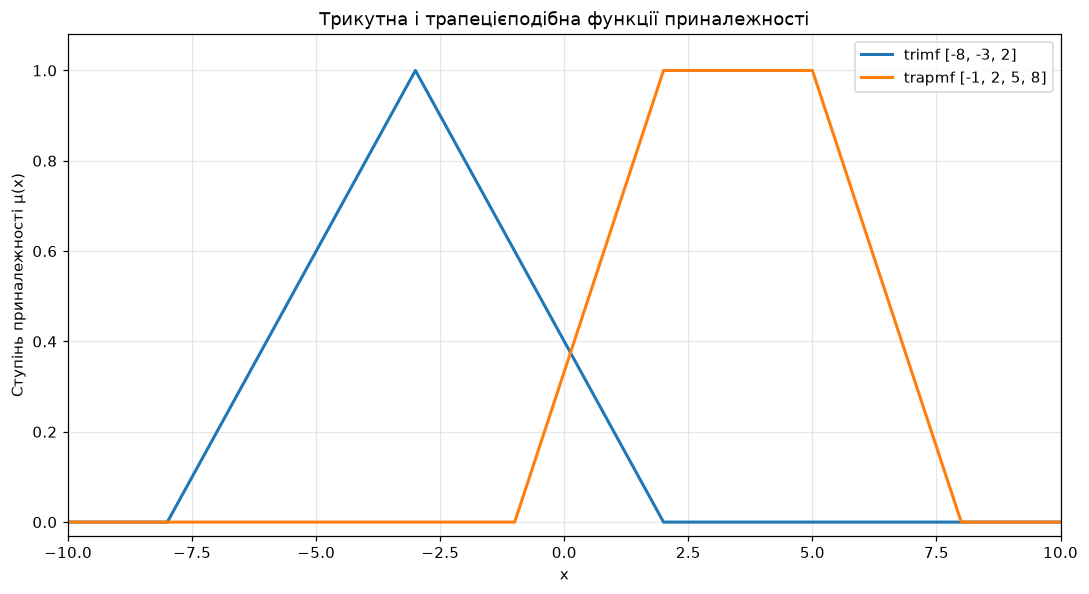

In [4]:
mu_tri = fuzz.trimf(x, TRI)
mu_trap = fuzz.trapmf(x, TRAP)
plt.plot(x, mu_tri, lw=2, label=f'trimf {TRI}')
plt.plot(x, mu_trap, lw=2, label=f'trapmf {TRAP}')
finish_plot('Трикутна і трапецієподібна функції приналежності', '01_tri_trap.png')

## 2. Проста та двосторонні гаусові функції

У `gaussmf` параметр `mean` переміщує центр, а `sigma` змінює ширину. У `gauss2mf` між `mean1` та `mean2` утворюється плато; дві `sigma` незалежно керують лівим і правим схилами.

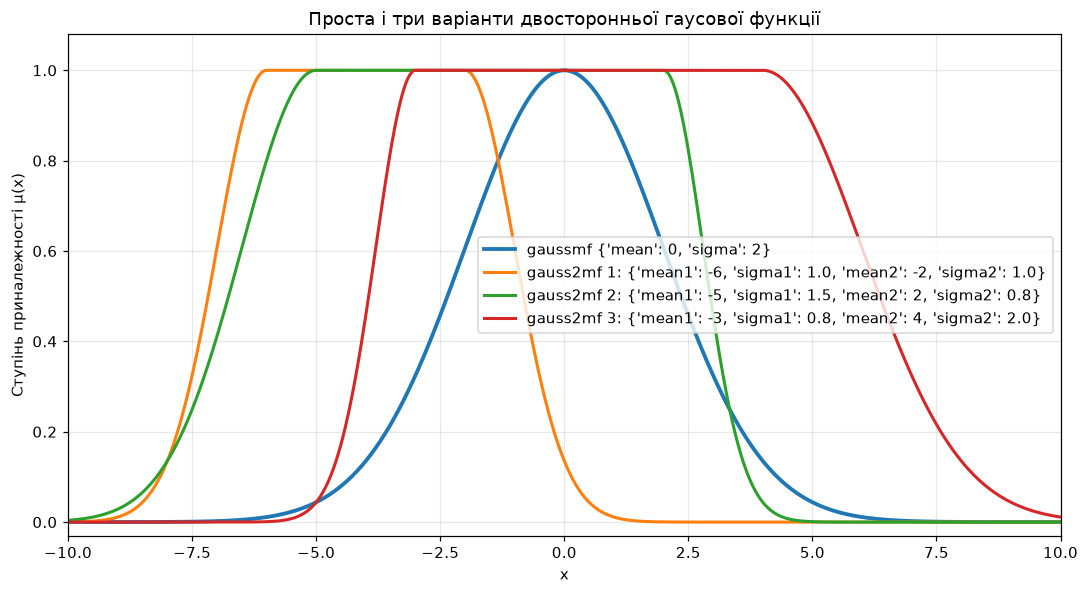

In [5]:
mu_gauss = fuzz.gaussmf(x, **GAUSS)
plt.plot(x, mu_gauss, lw=2.5, label=f'gaussmf {GAUSS}')
for i, params in enumerate(GAUSS2, start=1):
    mu = fuzz.gauss2mf(x, **params)
    plt.plot(x, mu, lw=2, label=f'gauss2mf {i}: {params}')
finish_plot('Проста і три варіанти двосторонньої гаусової функції', '02_gaussian.png')

## 3. Узагальнена дзвоноподібна функція

Параметр `c` визначає центр; збільшення `a` розширює дзвін; збільшення `b` робить переходи крутішими.

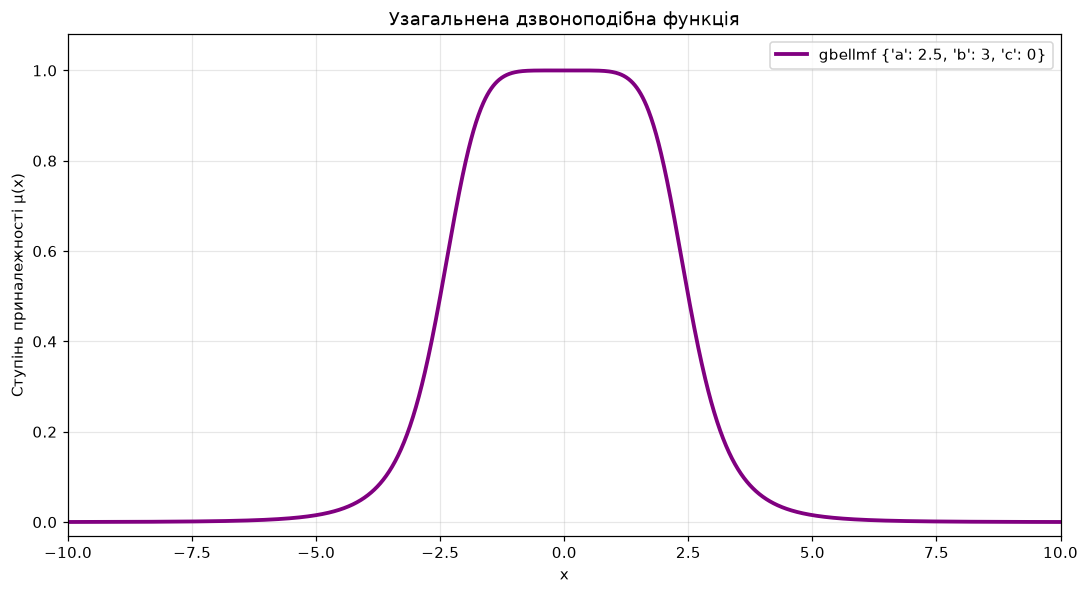

In [6]:
mu_gbell = fuzz.gbellmf(x, **GBELL)
plt.plot(x, mu_gbell, lw=2.5, color='purple', label=f'gbellmf {GBELL}')
finish_plot('Узагальнена дзвоноподібна функція', '03_gbell.png')

## 4. Сигмоїдальні функції

`sigmf` є одностороннім переходом. `dsigmf` — різниця двох сигмоїд, а `psigmf` — їх добуток. Знак `c` визначає напрям відкриття, модуль — крутизну. Вибрані різні модулі нахилів `PSIG` утворюють несиметричні краї.

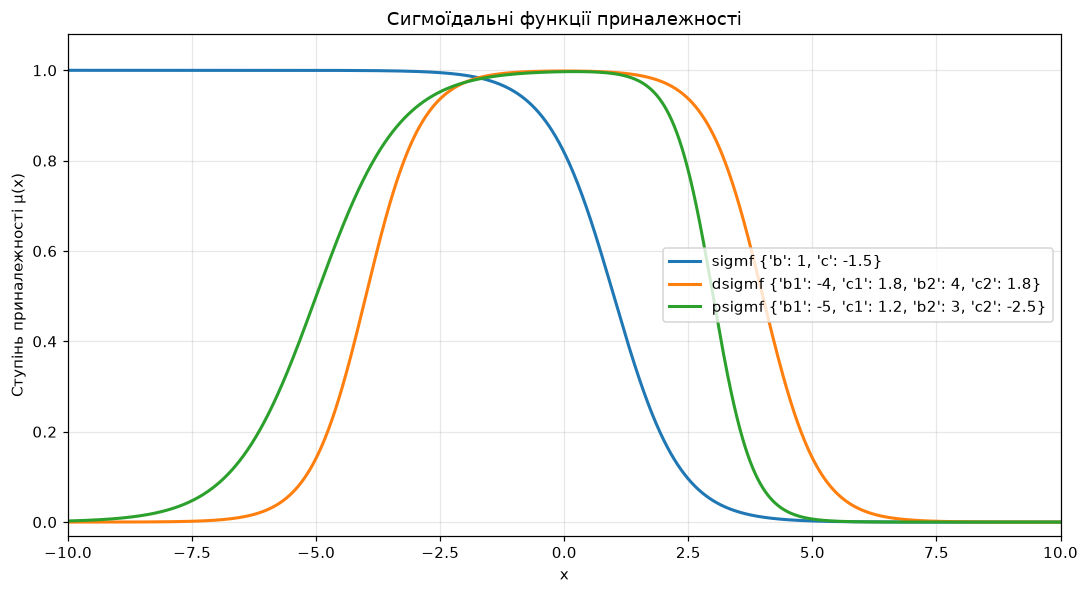

In [7]:
mu_sig = fuzz.sigmf(x, **SIG)
mu_dsig = fuzz.dsigmf(x, **DSIG)
mu_psig = fuzz.psigmf(x, **PSIG)
plt.plot(x, mu_sig, lw=2, label=f'sigmf {SIG}')
plt.plot(x, mu_dsig, lw=2, label=f'dsigmf {DSIG}')
plt.plot(x, mu_psig, lw=2, label=f'psigmf {PSIG}')
finish_plot('Сигмоїдальні функції приналежності', '04_sigmoid.png')

## 5. Поліноміальні Z-, PI- та S-функції

Для `zmf` повна приналежність лежить ліворуч від `a`, часткова — між `a` і `b`, нульова — праворуч від `b`. Для `smf` ці ділянки розташовані навпаки. У `pimf` нульові зовнішні ділянки переходять через часткові ділянки до плато 1 на відрізку `[b, c]`.

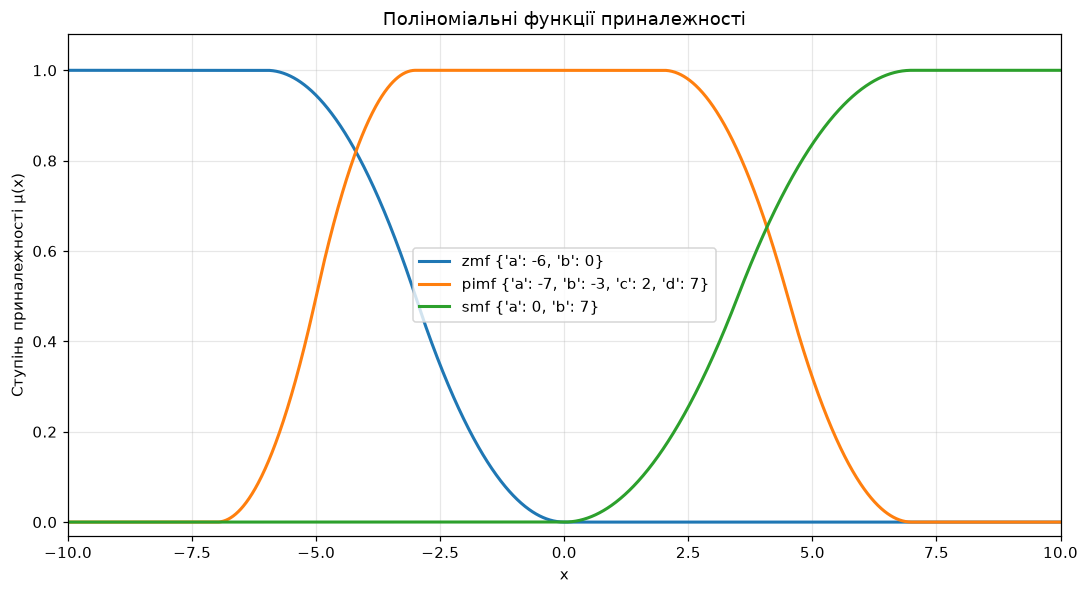

In [8]:
mu_z = fuzz.zmf(x, **Z_PARAMS)
mu_pi = fuzz.pimf(x, **PI_PARAMS)
mu_s = fuzz.smf(x, **S_PARAMS)
plt.plot(x, mu_z, lw=2, label=f'zmf {Z_PARAMS}')
plt.plot(x, mu_pi, lw=2, label=f'pimf {PI_PARAMS}')
plt.plot(x, mu_s, lw=2, label=f'smf {S_PARAMS}')
finish_plot('Поліноміальні функції приналежності', '05_polynomial.png')

## 6. Мінімаксні операції

Перетин у кожній точці повторює нижчу з двох початкових кривих, а об’єднання — вищу.

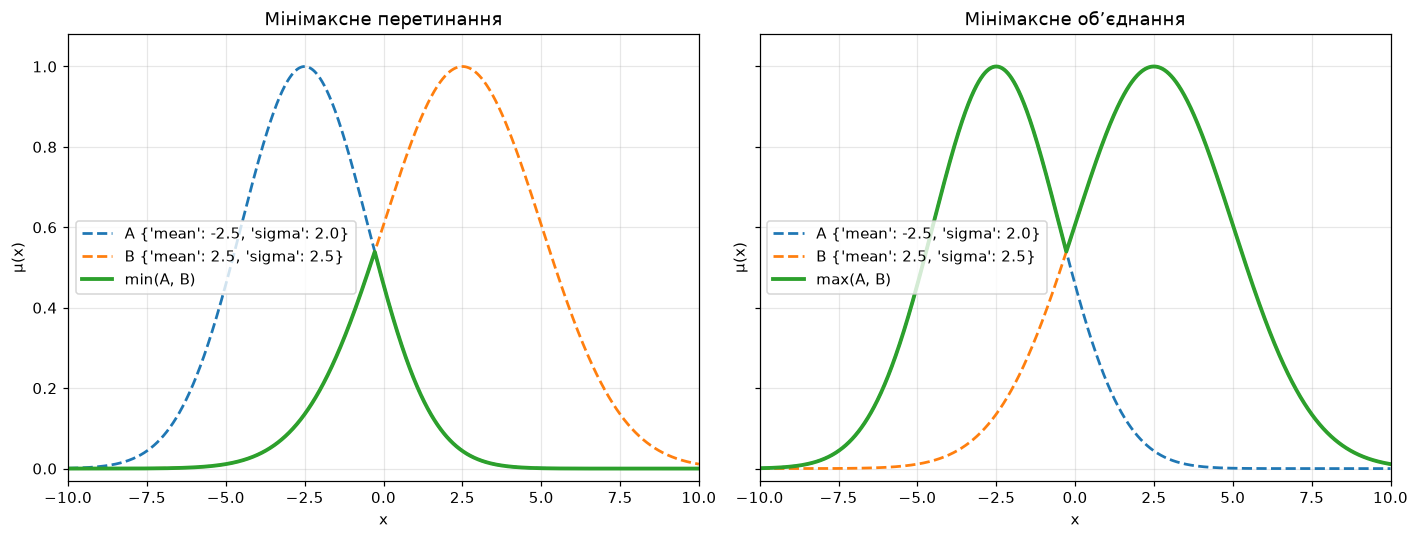

In [9]:
mu_a = fuzz.gaussmf(x, **SET_A)
mu_b = fuzz.gaussmf(x, **SET_B)
min_intersection = np.fmin(mu_a, mu_b)
max_union = np.fmax(mu_a, mu_b)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax in axes:
    ax.plot(x, mu_a, '--', lw=1.8, label=f'A {SET_A}')
    ax.plot(x, mu_b, '--', lw=1.8, label=f'B {SET_B}')
    ax.set(xlabel='x', ylabel='μ(x)', xlim=(X_MIN, X_MAX), ylim=(-0.03, 1.08))
    ax.grid(True, alpha=0.3); ax.legend()
axes[0].plot(x, min_intersection, lw=2.5, label='min(A, B)')
axes[0].set_title('Мінімаксне перетинання')
axes[0].legend()
axes[1].plot(x, max_union, lw=2.5, label='max(A, B)')
axes[1].set_title('Мінімаксне об’єднання')
axes[1].legend()
fig.tight_layout(); fig.savefig(FIGURES_DIR / '06_minmax.png', bbox_inches='tight'); plt.show()

## 7. Імовірнісні операції та порівняння

Спочатку наведено дві діаграми самих імовірнісних операцій: на кожній показано початкові множини A, B та відповідний результат. Далі дві окремі діаграми порівнюють ці результати з мінімаксною інтерпретацією. Алгебраїчний добуток не перевищує мінімаксного перетину, а алгебраїчна сума не менша за максимаксне об’єднання. Тому імовірнісні операції дають відповідно суворіше «І» та м’якше «АБО».

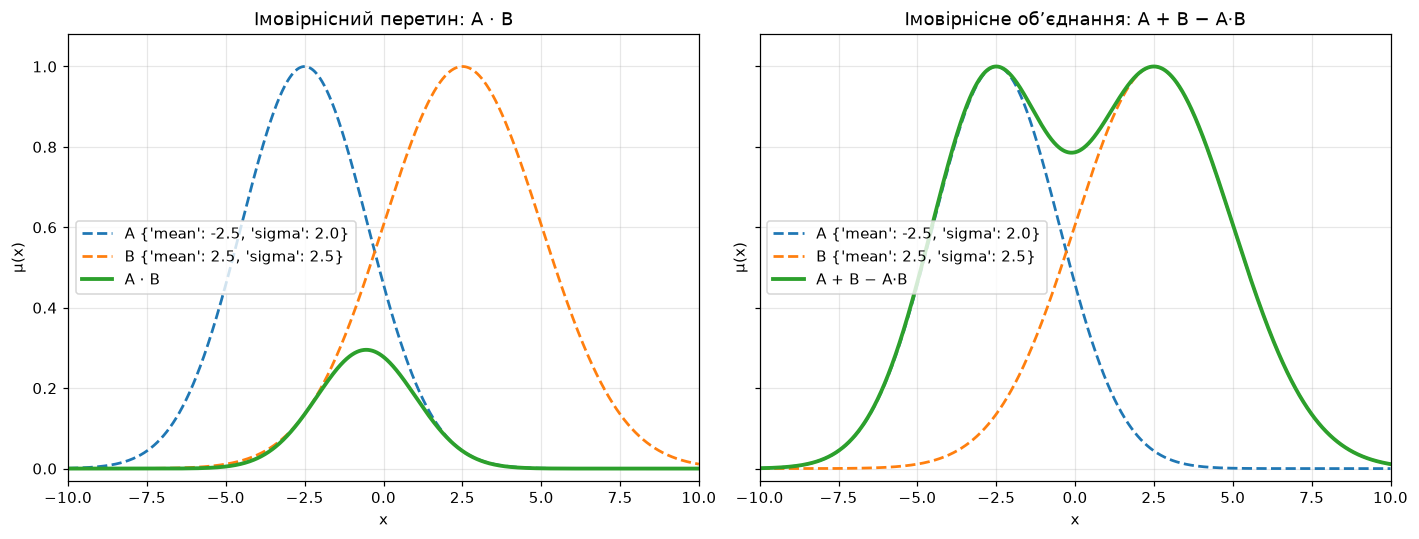

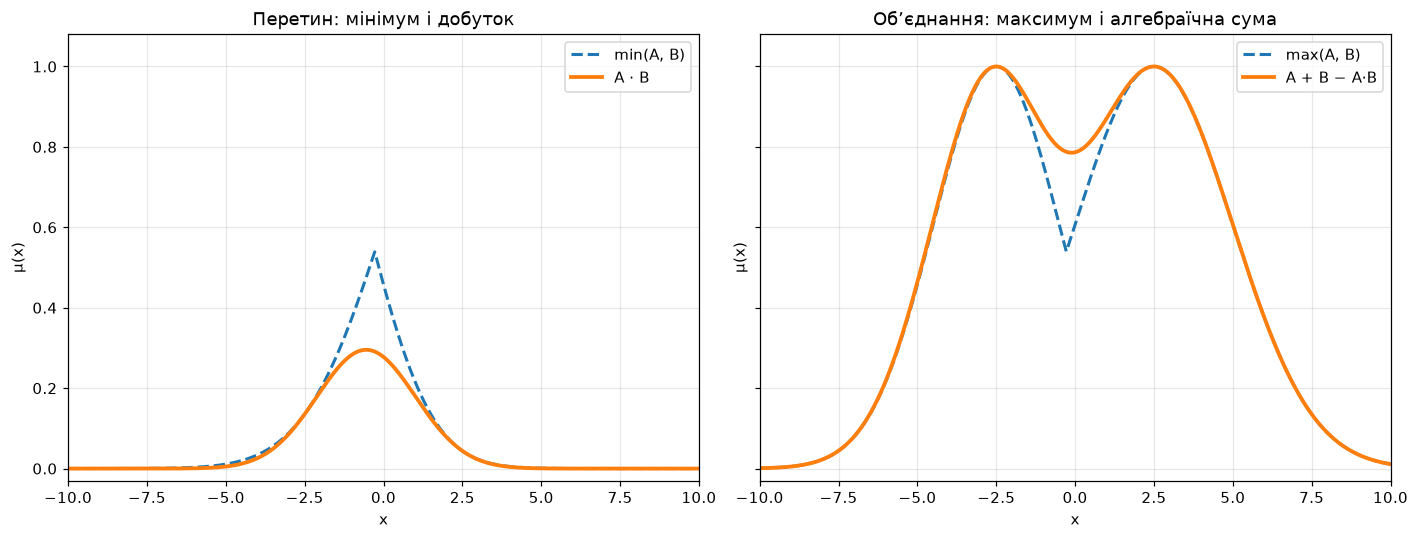

Добуток <= мінімум: True
Алгебраїчна сума >= максимум: True


In [10]:
algebraic_product = mu_a * mu_b
algebraic_sum = mu_a + mu_b - mu_a * mu_b

# Діаграми самих імовірнісних операцій разом із початковими A та B
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax in axes:
    ax.plot(x, mu_a, '--', lw=1.8, label=f'A {SET_A}')
    ax.plot(x, mu_b, '--', lw=1.8, label=f'B {SET_B}')
axes[0].plot(x, algebraic_product, lw=2.5, label='A · B')
axes[0].set_title('Імовірнісний перетин: A · B')
axes[1].plot(x, algebraic_sum, lw=2.5, label='A + B − A·B')
axes[1].set_title('Імовірнісне об’єднання: A + B − A·B')
for ax in axes:
    ax.set(xlabel='x', ylabel='μ(x)', xlim=(X_MIN, X_MAX), ylim=(-0.03, 1.08))
    ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES_DIR / '07_probabilistic.png', bbox_inches='tight'); plt.show()

# Діаграми порівняння імовірнісної та мінімаксної інтерпретацій
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
axes[0].plot(x, min_intersection, '--', lw=2, label='min(A, B)')
axes[0].plot(x, algebraic_product, lw=2.5, label='A · B')
axes[0].set_title('Перетин: мінімум і добуток')
axes[1].plot(x, max_union, '--', lw=2, label='max(A, B)')
axes[1].plot(x, algebraic_sum, lw=2.5, label='A + B − A·B')
axes[1].set_title('Об’єднання: максимум і алгебраїчна сума')
for ax in axes:
    ax.set(xlabel='x', ylabel='μ(x)', xlim=(X_MIN, X_MAX), ylim=(-0.03, 1.08))
    ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES_DIR / '08_probabilistic_comparison.png', bbox_inches='tight'); plt.show()
print('Добуток <= мінімум:', np.all(algebraic_product <= min_intersection + 1e-12))
print('Алгебраїчна сума >= максимум:', np.all(algebraic_sum + 1e-12 >= max_union))

## 8. Доповнення та α-зріз

Нехай множина A описує судження «значення x є близьким до центра A». Тоді її доповнення означає «значення x не є близьким до центра A». У кожній точці сума ступенів цих протилежних суджень дорівнює 1.

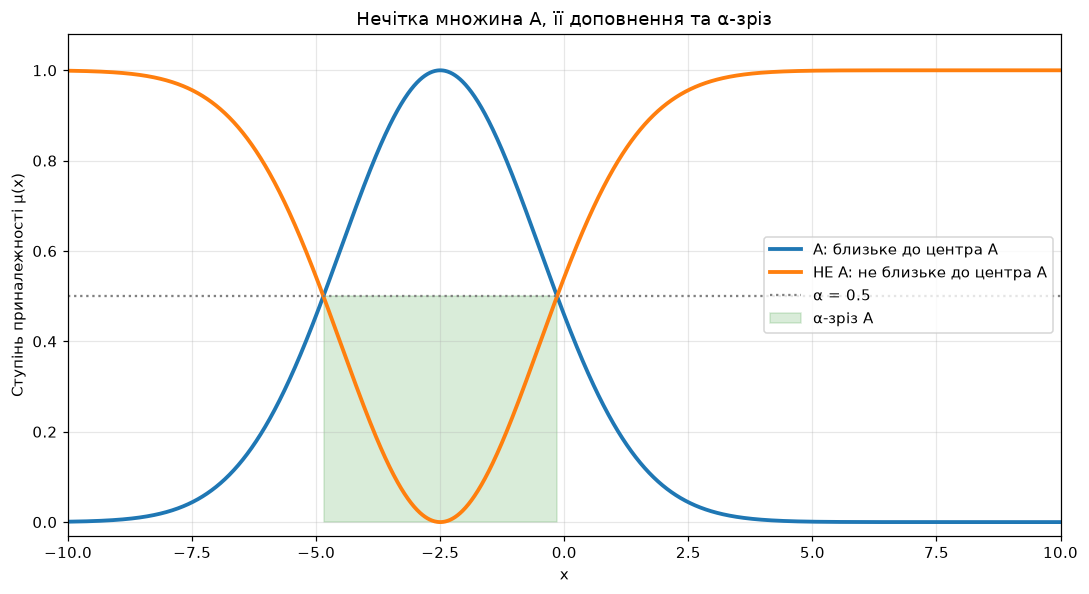

Максимальна похибка рівності μA + μне-A = 1: 0.0
α-зріз A для α=0.5: приблизно [-4.85; -0.15]


In [11]:
mu_not_a = 1 - mu_a
alpha_mask = mu_a >= ALPHA
plt.plot(x, mu_a, lw=2.5, label='A: близьке до центра A')
plt.plot(x, mu_not_a, lw=2.5, label='НЕ A: не близьке до центра A')
plt.axhline(ALPHA, color='gray', ls=':', label=f'α = {ALPHA}')
plt.fill_between(x, 0, ALPHA, where=alpha_mask, color='green', alpha=0.15, label='α-зріз A')
finish_plot('Нечітка множина A, її доповнення та α-зріз', '09_complement_alpha.png')
print('Максимальна похибка рівності μA + μне-A = 1:', np.max(np.abs(mu_a + mu_not_a - 1)))
if np.any(alpha_mask):
    print(f'α-зріз A для α={ALPHA}: приблизно [{x[alpha_mask][0]:.2f}; {x[alpha_mask][-1]:.2f}]')

## 9. Підсумкова самоперевірка

Усі масиви повинні мати однакову довжину, значення — належати `[0; 1]`, а файли графіків — бути створеними.

In [12]:
all_sets = {
    'tri': mu_tri, 'trap': mu_trap, 'gauss': mu_gauss, 'gbell': mu_gbell,
    'sig': mu_sig, 'dsig': mu_dsig, 'psig': mu_psig,
    'z': mu_z, 'pi': mu_pi, 's': mu_s, 'A': mu_a, 'B': mu_b,
    'min intersection': min_intersection, 'max union': max_union,
    'algebraic product': algebraic_product, 'algebraic sum': algebraic_sum,
    'not A': mu_not_a,
}
assert all(values.shape == x.shape for values in all_sets.values())
assert all(np.all(np.isfinite(values)) for values in all_sets.values())
assert all(np.all((values >= -1e-12) & (values <= 1 + 1e-12)) for values in all_sets.values())
expected = [
    '01_tri_trap.png', '02_gaussian.png', '03_gbell.png', '04_sigmoid.png',
    '05_polynomial.png', '06_minmax.png', '07_probabilistic.png',
    '08_probabilistic_comparison.png', '09_complement_alpha.png',
]
assert all((FIGURES_DIR / name).exists() for name in expected)
print(f'Самоперевірку пройдено: {len(all_sets)} масивів, {len(expected)} графіків.')
print('Файли:', ', '.join(expected))

Самоперевірку пройдено: 17 масивів, 9 графіків.
Файли: 01_tri_trap.png, 02_gaussian.png, 03_gbell.png, 04_sigmoid.png, 05_polynomial.png, 06_minmax.png, 07_probabilistic.png, 08_probabilistic_comparison.png, 09_complement_alpha.png


## Висновок

У роботі побудовано основні типи функцій приналежності. Параметри центрів зсувають криві вздовж універсуму, параметри ширини змінюють область часткової приналежності, а параметри нахилу/крутизни визначають різкість переходів. Мінімаксні операції вибирають одну з початкових ординат у кожній точці; алгебраїчні операції формують нові значення. Доповнення інвертує ступінь приналежності та задовольняє рівність $\mu_A(x)+\mu_{\bar A}(x)=1$.